In [2]:
import numpy as np
import pandas as pd
from keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix


In [3]:
model_path = r"C:\Users\21629\Desktop\PFE\modéle ANN basée aal MIBBIH\model_ann_mitbih.h5"
model = load_model(model_path)
print("Model loaded successfully!")


Model loaded successfully!


In [4]:
test_data_path = r"C:\Users\21629\Desktop\PFE\modéle (CNN) 1D basée aal mitbih\mitbih_test.csv\mitbih_test.csv"
df_test = pd.read_csv(test_data_path, header=None)

Y_test = np.array(df_test[187].values).astype(np.int8)
X_test = np.array(df_test[list(range(187))].values)[..., np.newaxis]


In [7]:
# Faire des prédictions
pred_test = model.predict(X_test)
pred_test = np.argmax(pred_test, axis=-1)

# Afficher le F1-score et l'accuracy
print("Test F1 Score:", classification_report(Y_test, pred_test))
print("Confusion Matrix:\n", confusion_matrix(Y_test, pred_test))


685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Test F1 Score:               precision    recall  f1-score   support

           0       0.99      0.97      0.98     18118
           1       0.69      0.81      0.75       556
           2       0.90      0.95      0.92      1448
           3       0.56      0.84      0.67       162
           4       0.95      0.99      0.97      1608

    accuracy                           0.97     21892
   macro avg       0.82      0.91      0.86     21892
weighted avg       0.97      0.97      0.97     21892

Confusion Matrix:
 [[17661   186   131    77    63]
 [   90   452     9     1     4]
 [   29    11  1371    29     8]
 [   11     1    13   136     1]
 [   13     1     7     1  1586]]


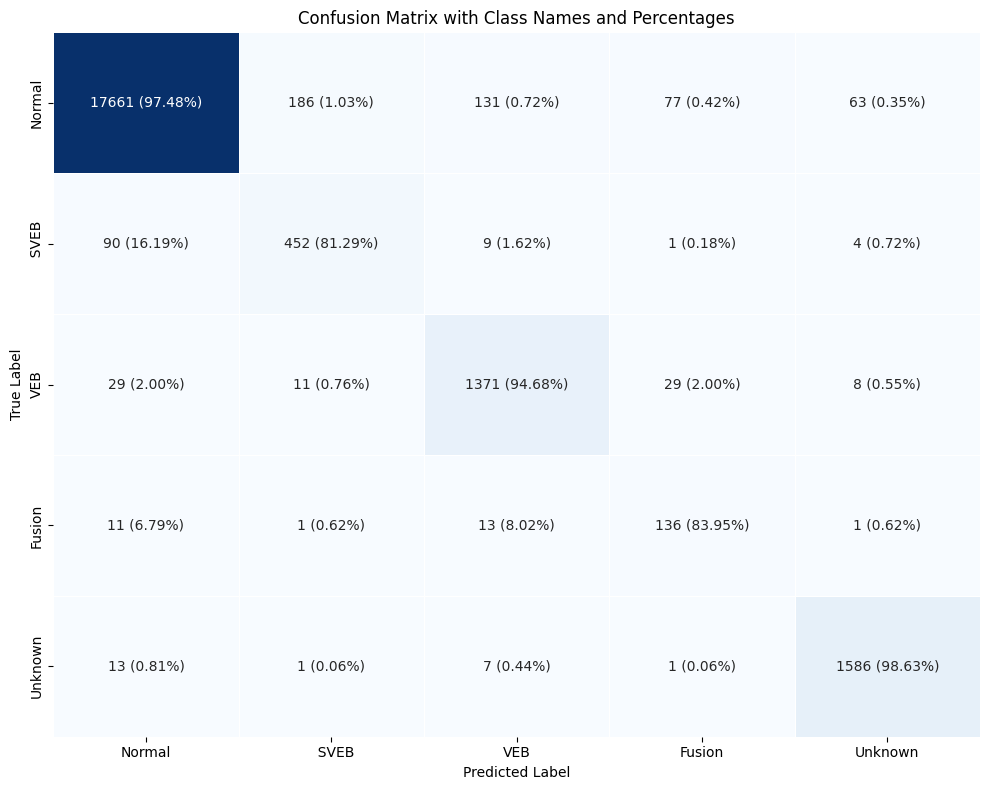

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Your class names
class_names = ["Normal", "  SVEB", "VEB", "Fusion", "Unknown"]

# Compute confusion matrix
conf_matrix = confusion_matrix(Y_test, pred_test)
cm_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Create labels with value and percentage
labels = np.array([
    [f"{conf_matrix[i, j]} ({cm_percent[i, j]:.2f}%)" for j in range(conf_matrix.shape[1])]
    for i in range(conf_matrix.shape[0])
])

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=labels, fmt="", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 10}, linewidths=0.5, cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix with Class Names and Percentages")
plt.tight_layout()
plt.show()
